<a href="https://colab.research.google.com/github/Nihat0311/Machine-Learning/blob/main/Linear_Regression/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!curl -L -o car-price-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/hellbuoy/car-price-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18523  100 18523    0     0  61254      0 --:--:-- --:--:-- --:--:-- 61254


In [ ]:
!unzip /content/car-price-prediction.zip

Archive:  /content/car-price-prediction.zip
  inflating: CarPrice_Assignment.csv  
  inflating: Data Dictionary - carprices.xlsx  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/CarPrice_Assignment.csv')

In [ ]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [ ]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

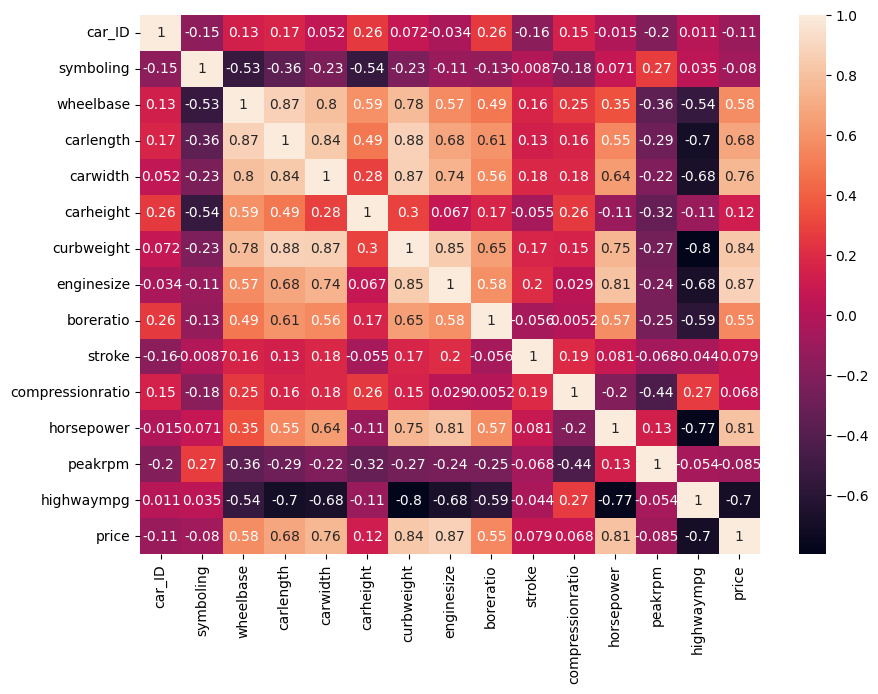

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
df=df.drop('citympg',axis=1)

In [ ]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,54.000000,45400.000000


In [ ]:
num_features=df.select_dtypes(include=np.number).columns
num_features

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'highwaympg', 'price'],
      dtype='object')

In [ ]:
outlier_dict={}
for i in num_features:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    outlier=df[(df[i]<lower_limit) | (df[i]>upper_limit)]
    outlier_dict[i]=outlier.shape[0]
outlier_dict

{'car_ID': 0,
 'symboling': 0,
 'wheelbase': 3,
 'carlength': 1,
 'carwidth': 8,
 'carheight': 0,
 'curbweight': 0,
 'enginesize': 10,
 'boreratio': 0,
 'stroke': 20,
 'compressionratio': 28,
 'horsepower': 6,
 'peakrpm': 2,
 'highwaympg': 3,
 'price': 15}

In [ ]:
def remove_outliers(df, features):

    Q1=df[features].quantile(0.25)
    Q3=df[features].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR


    df_clean=df[(df[features]>=lower_limit) & (df[features]<=upper_limit)]
    return df_clean

In [ ]:
df_clean=remove_outliers(df,'compressionratio')
df_clean

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154,5000,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102,5500,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115,5500,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,200,-1,volvo diesel,gas,turbo,four,wagon,rwd,front,104.3,...,four,130,mpfi,3.62,3.15,7.5,162,5100,22,18950.0
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,9.5,114,5400,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,four,141,mpfi,3.78,3.15,8.7,160,5300,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,six,173,mpfi,3.58,2.87,8.8,134,5500,23,21485.0


In [ ]:
# Train Test Split

In [ ]:
#y=wx+b

In [ ]:
X=df_clean.drop('price',axis=1)
y=df_clean['price'].copy()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_test.shape

(36, 24)

In [ ]:
X_train.shape

(141, 24)

In [ ]:
num_features=X_train.select_dtypes(include=np.number).columns
cat_features=X_train.select_dtypes(exclude=np.number).columns

In [ ]:
num_features

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'highwaympg'],
      dtype='object')

In [ ]:
cat_features

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

In [ ]:
X_train_num=X_train[num_features]
X_train_num

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,highwaympg
179,180,3,102.9,183.5,67.7,52.0,3016,171,3.27,3.35,9.3,161,5200,24
156,157,0,95.7,166.3,64.4,53.0,2081,98,3.19,3.03,9.0,70,4800,37
115,116,0,107.9,186.7,68.4,56.7,3075,120,3.46,3.19,8.4,97,5000,24
181,182,-1,104.5,187.8,66.5,54.1,3151,161,3.27,3.35,9.2,156,5200,24
40,41,0,96.5,175.4,62.5,54.1,2372,110,3.15,3.58,9.0,86,5800,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,81,3,96.3,173.0,65.4,49.4,2370,110,3.17,3.46,7.5,116,5500,30
126,127,3,89.5,168.9,65.0,51.6,2756,194,3.74,2.90,9.5,207,5900,25
15,16,0,103.5,189.0,66.9,55.7,3230,209,3.62,3.39,8.0,182,5400,22
105,106,3,91.3,170.7,67.9,49.7,3139,181,3.43,3.27,7.8,200,5200,23


In [ ]:
# fit / transform / fit_transform

In [ ]:
# Scale
#Standart Scale
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X_train_num)


StandardScaler()

In [ ]:
X_scaled=sc.transform(X_train_num)
X_scaled

array([[ 1.28801834,  1.71017688,  0.86633415, ...,  1.68434097,
         0.03230222, -1.03692238],
       [ 0.90196996, -0.68520332, -0.41219824, ..., -0.91291645,
        -0.90197726,  1.00243247],
       [ 0.21379676, -0.68520332,  1.75420387, ..., -0.14230161,
        -0.43483752, -1.03692238],
       ...,
       [-1.46467445, -0.68520332,  0.97287852, ...,  2.28370807,
         0.49944196, -1.35066928],
       [ 0.04594964,  1.71017688, -1.19352359, ...,  2.79745129,
         0.03230222, -1.19379583],
       [ 0.31450503,  0.11325675, -0.76734613, ..., -0.96999903,
         0.73301183,  1.15930592]])

In [ ]:
X_test_num=X_test[num_features]
X_test_num

In [ ]:
#Encode

In [ ]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data={'education' :['high-school','bachelor','master','phd'],
      'size': ['X','S','M','L']}
df=pd.DataFrame(data)
df

,education,size
0,high-school,X
1,bachelor,S
2,master,M
3,phd,L


In [ ]:
le=LabelEncoder()
le.fit_transform(df["education"])

array([1, 0, 2, 3])

In [ ]:
order_education=['high-school','bachelor','master','phd']
size_order=['X','S','M','L']
oe=OrdinalEncoder(categories=[order_education,size_order])
oe.fit_transform(df)

array([[0., 0.],
       [1., 1.],
       [2., 2.],
       [3., 3.]])

In [ ]:
oe.fit_transform(df[['education']])

array([[1.],
       [0.],
       [2.],
       [3.]])

In [ ]:
#OneHotEncoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df

,education,size
0,high-school,X
1,bachelor,S
2,master,M
3,phd,L


In [ ]:
ohe=OneHotEncoder(sparse_output=False) #sparse dense
ohe.fit_transform(df[['education']])

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [ ]:
pd.DataFrame(ohe.fit_transform(df),columns=ohe.get_feature_names_out())

,education_bachelor,education_high-school,education_master,education_phd,size_L,size_M,size_S,size_X
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [ ]:
df_dummy=pd.get_dummies(df,drop_first=True,dtype=int)
df_dummy

,education_high-school,education_master,education_phd,size_M,size_S,size_X
0,1,0,0,0,0,1
1,0,0,0,0,1,0
2,0,1,0,1,0,0
3,0,0,1,0,0,0
